In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
president_county = pd.read_csv("4-US_Election_2020/president_county.csv")
president_cand = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")

senator_county = pd.read_csv("4-US_Election_2020/senate_county.csv")
senator_cand = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

governor_county = pd.read_csv("4-US_Election_2020/governors_county.csv")
governor_cand = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

In [3]:
president_merged = pd.merge(president_cand, president_county, on = ["state", "county"], how = "left")
senator_merged = pd.merge(senator_cand, senator_county, on = ["state", "county"], how = "left")
governor_merged = pd.merge(governor_cand, governor_county, on = ["state", "county"], how = "left")

In [4]:
def clean_election(df):
    df["state"] = df["state"].str.strip()
    df["county"] = df["county"].str.strip()
    df["party"] = df["party"].str.strip()

    df["party"] = df["party"].replace({"DEM": "DEMOCRAT", "REP": "REPUBLICAN"})
    df = df.query("party == 'DEMOCRAT' or party == 'REPUBLICAN'")

    if "total_votes_x" in df.columns:
        df = df.rename(columns={"total_votes_x": "candidate_votes"})
    elif "votes" in df.columns:
        df = df.rename(columns={"votes": "candidate_votes"})
    elif "total_votes" in df.columns:
        df = df.rename(columns={"total_votes": "candidate_votes"})

    # county total always from county file
    if "current_votes" in df.columns:
        df = df.rename(columns={"current_votes": "county_total"})
    elif "total_votes_y" in df.columns:
        df = df.rename(columns={"total_votes_y": "county_total"})

    return df[["state", "county", "party", "candidate_votes", "county_total"]]

In [5]:
president_clean = clean_election(president_merged)
senator_clean = clean_election(senator_merged)
governor_clean = clean_election(governor_merged)

print(f"Number of rows found: {len(president_clean)}")
display(president_clean.head())
print(f"Number of rows found: {len(senator_clean)}")
display(senator_clean.head())
print(f"Number of rows found: {len(governor_clean)}")
display(governor_clean.head())

Number of rows found: 9266


,state,county,party,candidate_votes,county_total
0,Delaware,Kent County,DEMOCRAT,44552,87025
1,Delaware,Kent County,REPUBLICAN,41009,87025
4,Delaware,New Castle County,DEMOCRAT,195034,287633
5,Delaware,New Castle County,REPUBLICAN,88364,287633
8,Delaware,Sussex County,REPUBLICAN,71230,129352


Number of rows found: 7964


,state,county,party,candidate_votes,county_total
0,Delaware,Kent County,REPUBLICAN,38571,84975
3,Delaware,New Castle County,REPUBLICAN,80081,279462
6,Delaware,Sussex County,DEMOCRAT,56137,126498
9,Georgia,Appling County,DEMOCRAT,1753,8187
10,Georgia,Appling County,DEMOCRAT,1753,8159


Number of rows found: 2050


,state,county,party,candidate_votes,county_total
0,Delaware,Kent County,DEMOCRAT,44352,85415
1,Delaware,Kent County,REPUBLICAN,39332,85415
4,Delaware,New Castle County,DEMOCRAT,191678,280039
5,Delaware,New Castle County,REPUBLICAN,82545,280039
8,Delaware,Sussex County,REPUBLICAN,68435,127181


In [14]:
#PRESIDENT 
president_clean['vote_share'] = (president_clean['candidate_votes'] / president_clean['county_total']) * 100

county_bins = [0, 50000, 1000000, np.inf]
county_labels = ["rural", "suburban", "urban"]

president_clean["county_size"] = pd.cut(president_clean["county_total"],
                                        bins = county_bins,
                                        labels = county_labels)

president_graph = president_clean.groupby(["county_size", "party"]).agg(
    avg_vote_share=('vote_share', 'mean')).reset_index()



# SENATE
senator_clean['vote_share'] = (senator_clean['candidate_votes'] / senator_clean['county_total']) * 100

senator_clean['county_size'] = pd.cut(senator_clean['county_total'],
                                      bins = county_bins,
                                      labels = county_labels)

senator_graph = senator_clean.groupby(["county_size", "party"]).agg(
    avg_vote_share=('vote_share', 'mean')).reset_index()



# GOVERNOR
governor_clean['vote_share'] = (governor_clean['candidate_votes'] / governor_clean['county_total']) * 100

governor_clean['county_size'] = pd.cut(governor_clean['county_total'],
                                       bins = county_bins,
                                       labels = county_labels)

governor_graph = governor_clean.groupby(["county_size", "party"]).agg(
    avg_vote_share=('vote_share', 'mean')).reset_index()

/var/folders/22/c9dly99x2zz99bqrh67frh8h0000gn/T/ipykernel_52820/2888050802.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  president_graph = president_clean.groupby(["county_size", "party"]).agg(
/var/folders/22/c9dly99x2zz99bqrh67frh8h0000gn/T/ipykernel_52820/2888050802.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  senator_graph = senator_clean.groupby(["county_size", "party"]).agg(
/var/folders/22/c9dly99x2zz99bqrh67frh8h0000gn/T/ipykernel_52820/2888050802.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

In [7]:
def plot_bar(df, title):
    plt.figure(figsize=(10, 6))
    sizes = ["rural", "suburban", "urban"]
    dem = df[df["party"] == "DEMOCRAT"]["avg_vote_share"]
    rep = df[df["party"] == "REPUBLICAN"]["avg_vote_share"]
    x = np.arange(len(sizes))
    width = 0.35

    plt.bar(x - width/2, dem, width, label = "DEMOCRAT", color = "blue")
    plt.bar(x + width/2, rep, width, label = "REPUBLICAN", color = "red")
    plt.xticks(x, sizes)
    plt.ylabel("Average Vote Share (%) ") 
    plt.xlabel("County Size (based on total votes)") 
    plt.title(title)
    plt.legend()
    plt.show()


In [9]:
def plot_urban_rural(df, title):
    df['vote_share'] = (df['candidate_votes'] / df['county_total']) * 100

    plt.figure(figsize = (12, 6))
    for party, color in [('DEMOCRAT', 'blue'), ('REPUBLICAN', 'red')]:
        subset = df[df['party'] == party]
        plt.scatter(subset['county_total'], subset['vote_share'], 
                    color = color, alpha = 0.2, label = party, s = 10)
    
    plt.title(title)
    plt.xlabel("Total County Votes")
    plt.ylabel("Vote share %")
    plt.legend()
    plt.show()

In [16]:
def plot_bar_simple(df, title): 
    plt.figure(figsize=(10,6))

    sizes = ["rural", "suburban", "urban"]
    
    dem_vals = []
    rep_vals = []
    
    for size in sizes:
        dem = df[(df["county_size"] == size) & (df["party"] == "DEMOCRAT")]
        rep = df[(df["county_size"] == size) & (df["party"] == "REPUBLICAN")]
        dem_vals.append(dem["avg_vote_share"].values[0])
        rep_vals.append(rep["avg_vote_share"].values[0])
    
    x = [0, 1, 2]
    
    plt.bar(x, dem_vals, width = 0.4, label = "DEMOCRAT", color = "blue") 
    plt.bar([0.4, 1.4, 2.4], rep_vals, width = 0.4, label = "REPUBLICAN" , color = "red")

    plt.xticks([0.2, 1.2, 2.2], sizes)
    
    plt.xlabel ("County Size")
    plt.ylabel("'Average Vote Share (%)")
    plt.title(title)
    plt.legend()
    plt.show()

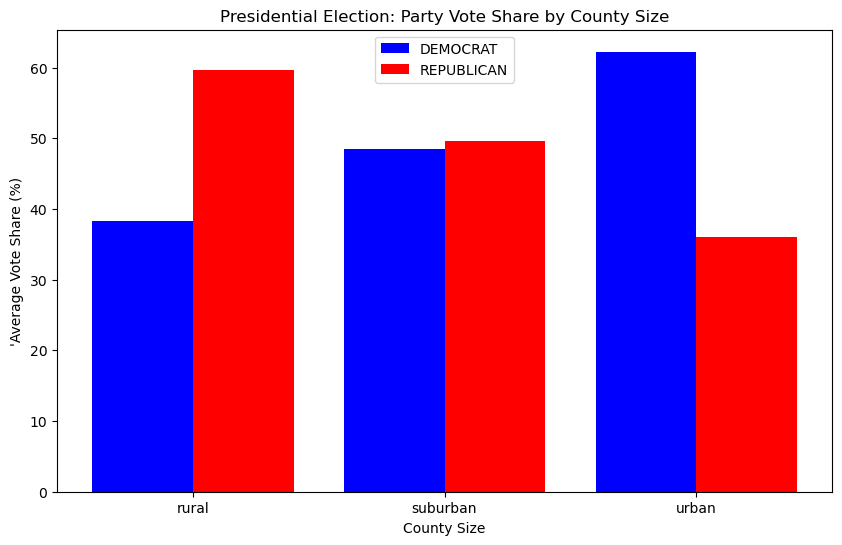

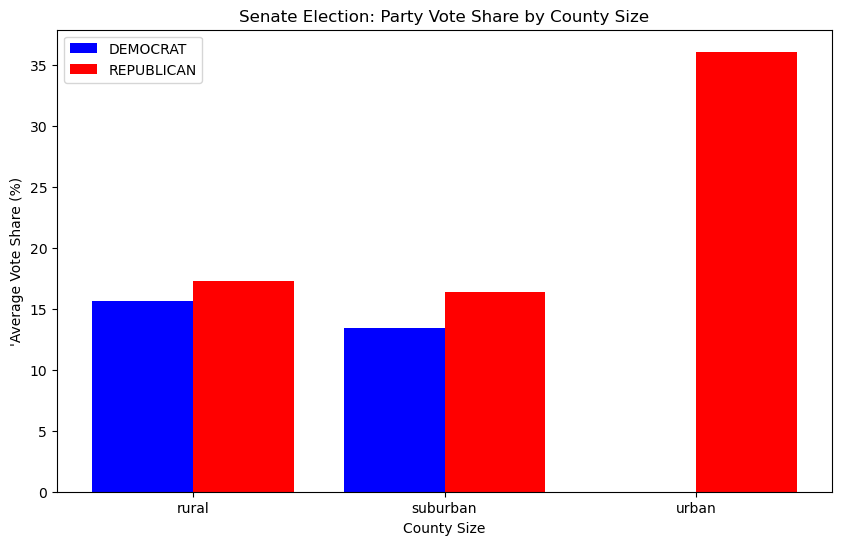

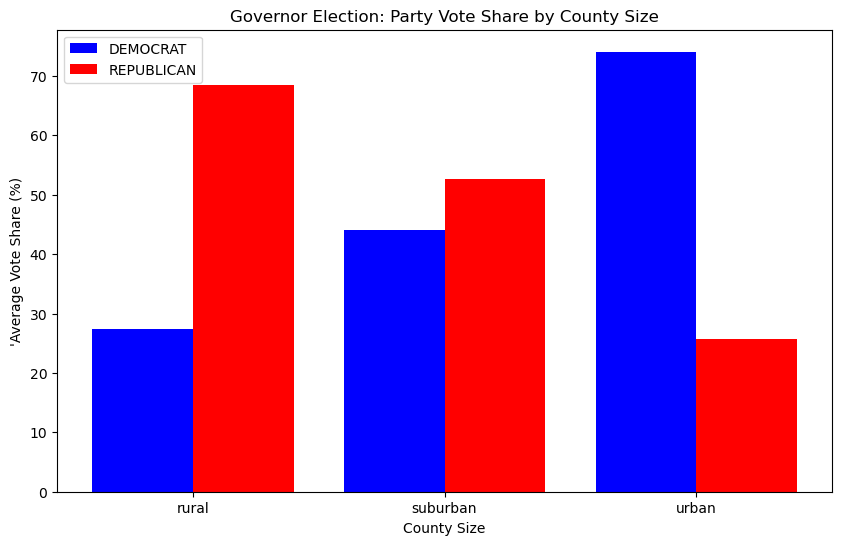

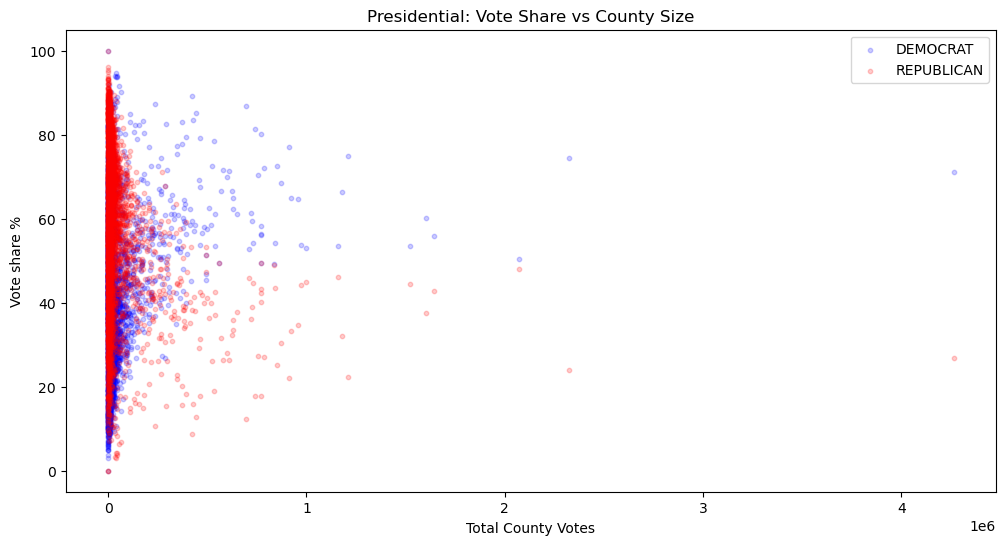

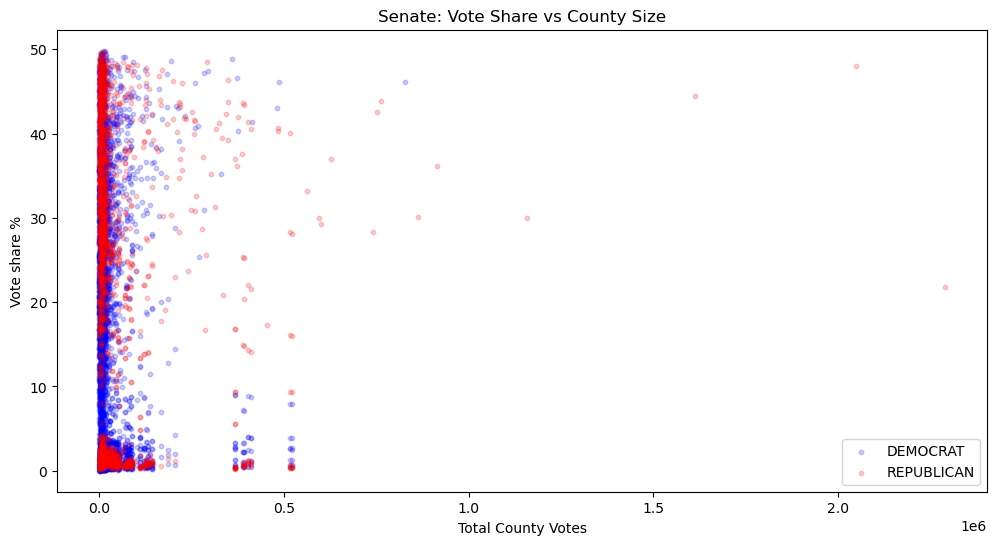

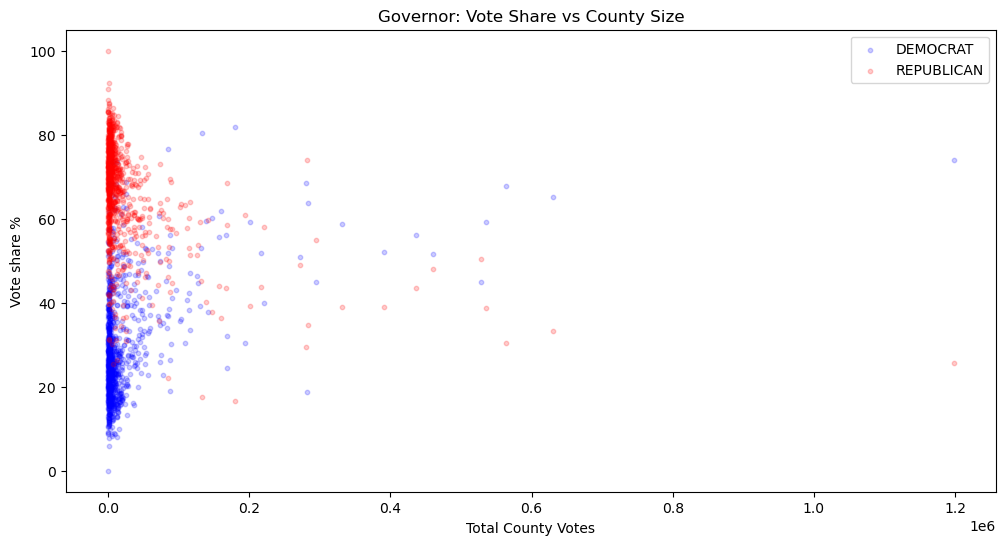

In [17]:
plot_bar_simple(president_graph, "Presidential Election: Party Vote Share by County Size")
plot_bar_simple(senator_graph, "Senate Election: Party Vote Share by County Size")
plot_bar_simple(governor_graph, "Governor Election: Party Vote Share by County Size")

plot_urban_rural(president_clean, "Presidential: Vote Share vs County Size")
plot_urban_rural(senator_clean, "Senate: Vote Share vs County Size")
plot_urban_rural(governor_clean, "Governor: Vote Share vs County Size")

In [ ]:
president_graph["office"] = "President"
senator_graph["office"] = "Senate"
governor_graph["office"] = "Governor"

combined_graph = pd.concat([president_graph, senator_graph, governor_graph])

In [21]:
president_graph["office"] = "President"
senator_graph["office"] = "Senate"
governor_graph["office"] = "Governor"

combined = pd.concat([president_graph, senator_graph, governor_graph])

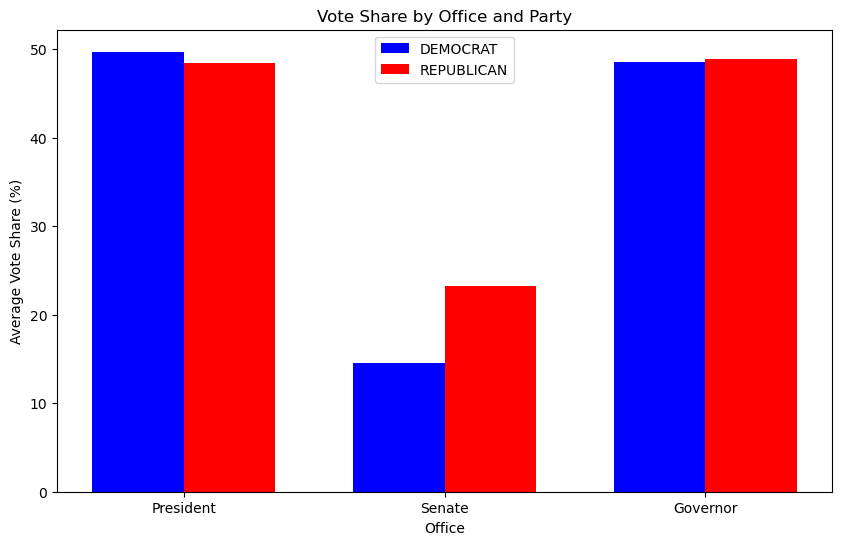

In [20]:
def plot_all_positions(df):
    plt.figure(figsize=(10,6))

    offices = ["President", "Senate", "Governor"]

    dem_vals = []
    rep_vals = []

    for office in offices:
        dem = df[(df["office"] == office) & (df["party"] == "DEMOCRAT")]
        rep = df[(df["office"] == office) & (df["party"] == "REPUBLICAN")]

        # average across all county sizes
        dem_vals.append(dem["avg_vote_share"].mean())
        rep_vals.append(rep["avg_vote_share"].mean())

    x = np.arange(len(offices))
    width = 0.35

    plt.bar(x - width/2, dem_vals, width, label="DEMOCRAT", color="blue")
    plt.bar(x + width/2, rep_vals, width, label="REPUBLICAN", color="red")

    plt.xticks(x, offices)

    plt.xlabel("Office")
    plt.ylabel("Average Vote Share (%)")
    plt.title("Vote Share by Office and Party")
    plt.legend()
    plt.show()

plot_all_positions(combined_graph)

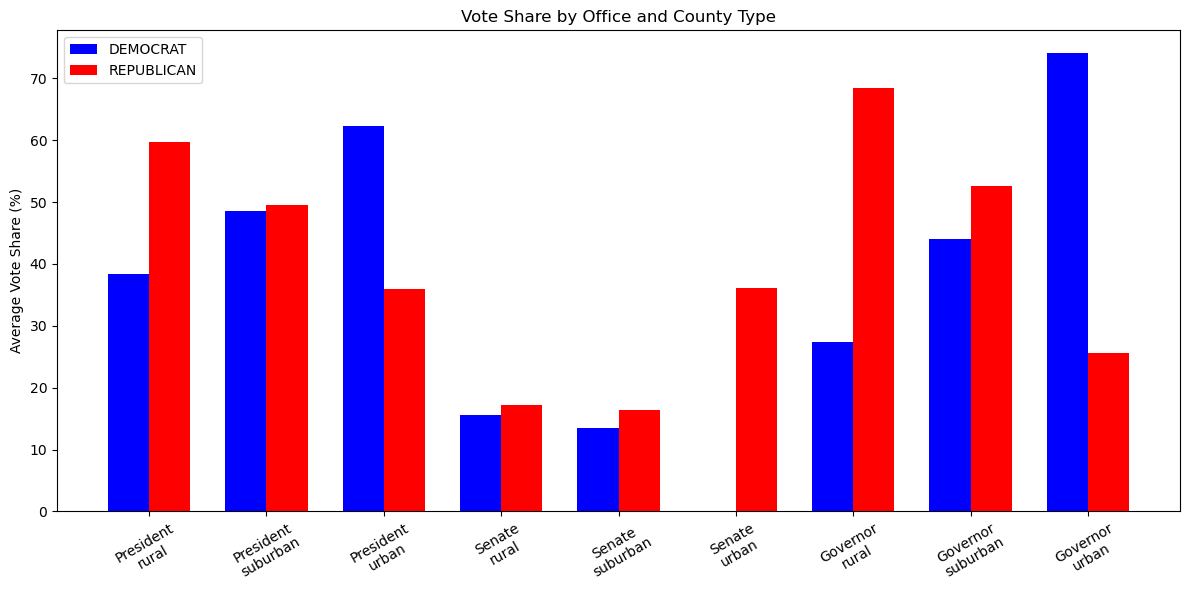

In [22]:
def plot_9_groups(df):
    plt.figure(figsize=(12,6))

    offices = ["President", "Senate", "Governor"]
    sizes = ["rural", "suburban", "urban"]

    x_labels = []
    dem_vals = []
    rep_vals = []

    # build 9 groups
    for office in offices:
        for size in sizes:
            subset = df[(df["office"] == office) & (df["county_size"] == size)]

            dem = subset[subset["party"] == "DEMOCRAT"]["avg_vote_share"]
            rep = subset[subset["party"] == "REPUBLICAN"]["avg_vote_share"]

            dem_vals.append(dem.values[0])
            rep_vals.append(rep.values[0])

            x_labels.append(f"{office}\n{size}")

    x = np.arange(len(x_labels))
    width = 0.35

    plt.bar(x - width/2, dem_vals, width, label="DEMOCRAT", color="blue")
    plt.bar(x + width/2, rep_vals, width, label="REPUBLICAN", color="red")

    plt.xticks(x, x_labels, rotation=30)
    plt.ylabel("Average Vote Share (%)")
    plt.title("Vote Share by Office and County Type")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_9_groups(combined)